## Imports

In [72]:
import psycopg2 
import pandas as pd
import numpy as np 
from faker import Faker
import os
from dotenv import load_dotenv
from datetime import timedelta

## Database Connection|

In [73]:
load_dotenv()
conn_string = os.getenv('NEON_URL')

conn = psycopg2.connect(conn_string)
cur = conn.cursor()

cur.execute("SELECT version();" )
print(cur.fetchone())

python-dotenv could not parse statement starting at line 7


('PostgreSQL 17.8 (92d3c18) on aarch64-unknown-linux-gnu, compiled by gcc (Debian 12.2.0-14+deb12u1) 12.2.0, 64-bit',)


## Table Queries

In [74]:
tables_query = """
SELECT 
    table_schema, table_name
FROM 
    information_schema.tables
WHERE 
    table_schema NOT IN ('pg_catalog', 'information_schema')
ORDER BY 
    table_schema, table_name;
"""
df_tables = pd.read_sql(tables_query, conn)
df_tables

/var/folders/5y/20qzsxn55txdbxf0jcdh23h00000gn/T/ipykernel_18668/3562565850.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_tables = pd.read_sql(tables_query, conn)


,table_schema,table_name
0,public,arrival_method
1,public,clinician
2,public,department
3,public,outcome
4,public,patient
5,public,triage_category
6,public,visit


## Variables

In [75]:
# Taken from the nhs admission analysis notebook.

baseline = {
    'avg_ae_attendances': 12006,
    'avg_over_4hrs': 3078,
    'avg_emergency_admissions': 2865,
    'avg_admission_rate': 18.02
}


config = {
    'n_months': 12,
    'start_date': '2025-04-01',
    'department_name': 'Emergency Department',
    'n_patients': 6000,
    'baseline': baseline,
    'n_clinicians': 40,
    'org_name': 'Synthetic NHS Trust',
    'parent_org': 'Synthetic NHS Region',
}

# Hardcoded Lookup Values

In [76]:
department_df = pd.DataFrame({'department_id': 1, 'department_name': [config['department_name']]})
department_df.to_csv('../data/synthetic/_department.csv', index=False)

In [77]:
triage_df = pd.DataFrame([
    {'triage_id': 1, 'triage_name': 'Life Threatening Conditions', 'priority': 1},
    {'triage_id': 2, 'triage_name': 'Very Urgent', 'priority': 2},
    {'triage_id': 3, 'triage_name': 'Urgent', 'priority': 3},
    {'triage_id': 4, 'triage_name': 'Not Threatening to Life & Limb', 'priority': 4},
    {'triage_id': 5, 'triage_name': 'Not Urgent', 'priority': 5},
])
triage_df.to_csv('../data/synthetic/_triage.csv', index=False)

In [78]:
arrival_method_df = pd.DataFrame([
    {'arrival_method_id': 1, 'arrival_method_name': 'Ambulance'},
    {'arrival_method_id': 2, 'arrival_method_name': 'Walk-in'},
    {'arrival_method_id': 3, 'arrival_method_name': 'GP'},
    {'arrival_method_id': 4, 'arrival_method_name': 'NHS 111'},
    {'arrival_method_id': 5, 'arrival_method_name': 'Police/Other Emergency Services'},
    {'arrival_method_id': 6, 'arrival_method_name': 'Other'},
])
arrival_method_df.to_csv('../data/synthetic/_arrival_method.csv', index=False)

In [79]:
outcome_df = pd.DataFrame([
    {'outcome_id': 1, 'outcome_name': 'Discharged'},
    {'outcome_id': 2, 'outcome_name': 'Admitted'},
    {'outcome_id': 3, 'outcome_name': 'Transferred'},
    {'outcome_id': 4, 'outcome_name': 'Left Before Treatment Complete'},
])
outcome_df.to_csv('../data/synthetic/_outcome.csv', index=False)

## Synthetic data

In [80]:
fake = Faker('en_GB')
np.random.seed(42)
Faker.seed(42)

### Patient Rows

In [81]:
postcode_areas = ['E', 'N', 'NW', 'SE', 'SW', 'W', 'WC']
sex_values = ['Male', 'Female', 'Other', 'Unknown']
sex_probs = [0.48, 0.48, 0.02, 0.02]

patients = []
for patient_num in range(1, config['n_patients'] + 1):
    age = np.random.randint(1, 100)
    dob = pd.Timestamp('2026-01-01') - pd.DateOffset(years=age) + pd.DateOffset(days=np.random.randint(0, 365))
    sex = np.random.choice(sex_values, p=sex_probs)
    
    patients.append({
        'patient_id': patient_num,
        'date_of_birth': dob.date(),
        'sex': sex,
        'postcode_area': np.random.choice(postcode_areas),
    })
    
    
    
patients_df = pd.DataFrame(patients)
patients_df.to_csv('../data/synthetic/_patients.csv', index=False)


### Clinicians

In [82]:
roles_pool = (
    ['Consultant'] * 6 +
    ['Registrar'] * 10 +
    ['Junior Doctor'] * 12 +
    ['Nurse'] * 6
)

clinicians = []
for clinician_id, role in enumerate(roles_pool[:config['n_clinicians']], start=1):
    clinicians.append({
        'department_id': 1,
        'clinician_role': role
    })

clinician_df = pd.DataFrame(clinicians)
clinician_df.to_csv('../data/synthetic/_clinicians.csv', index=False)


### Visits

In [83]:
monthly_visit_volume = int(config['baseline']['avg_ae_attendances'])
monthly_over4_volume = int(config['baseline']['avg_over_4hrs'])
monthly_admission_volume = int(config['baseline']['avg_emergency_admissions'])

#### Probability and Time to Assessent Distribution

Distributions are taken from https://pmc.ncbi.nlm.nih.gov/articles/PMC6805326/

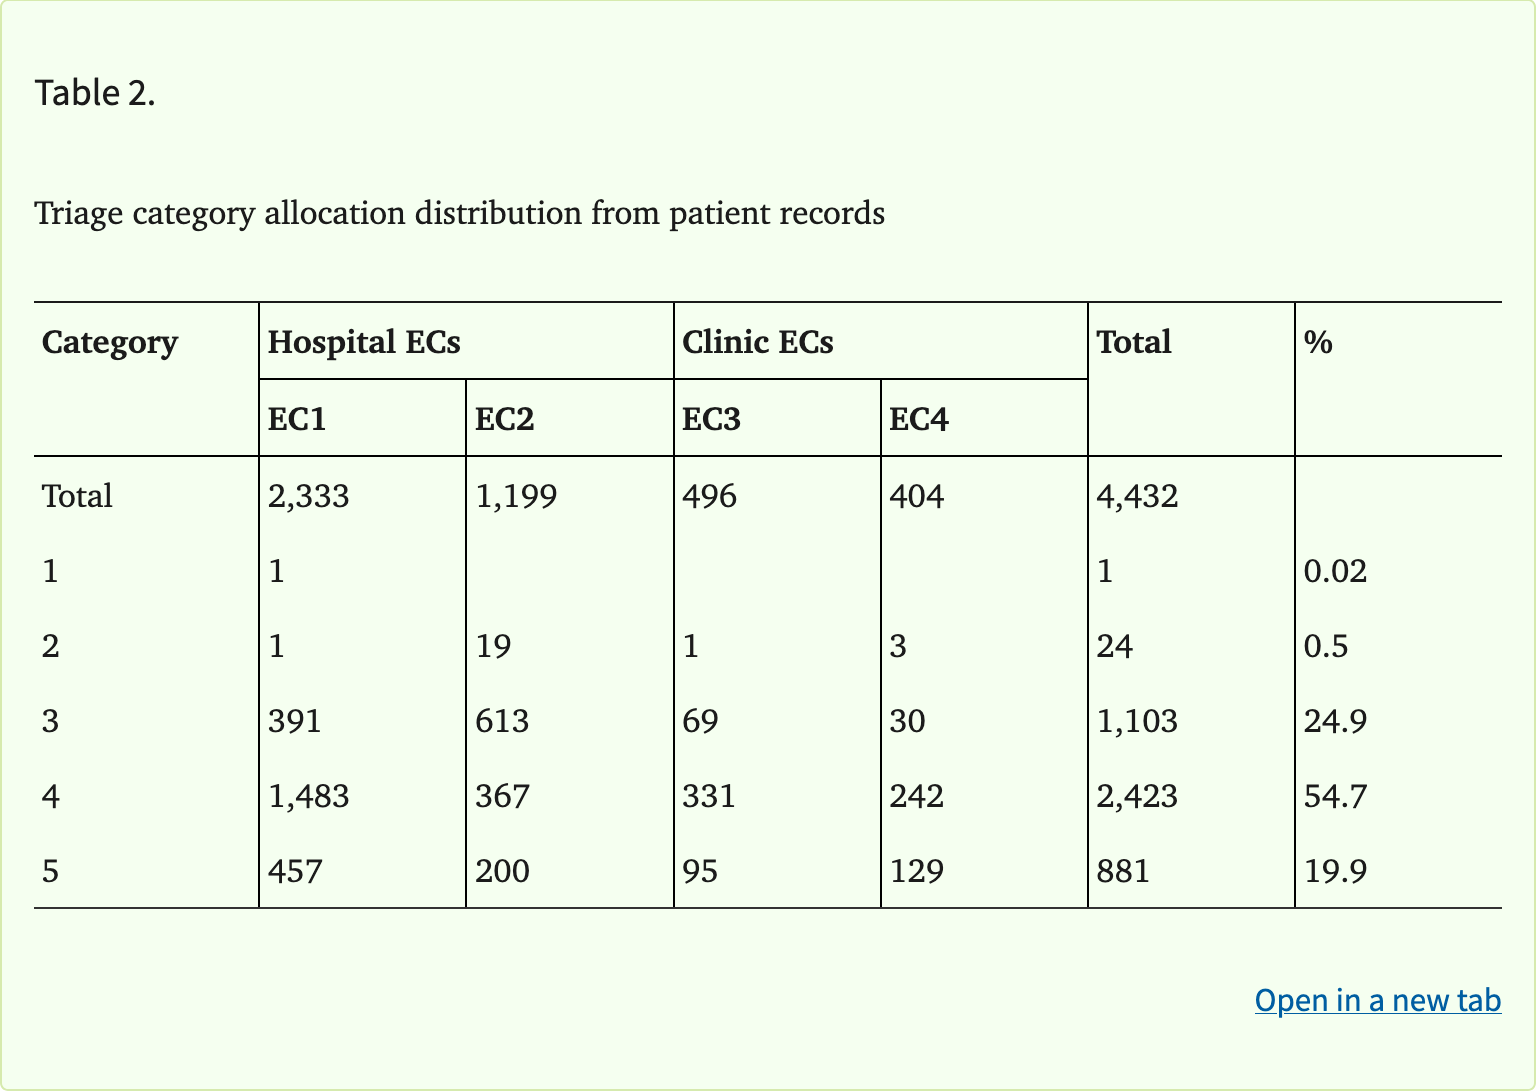

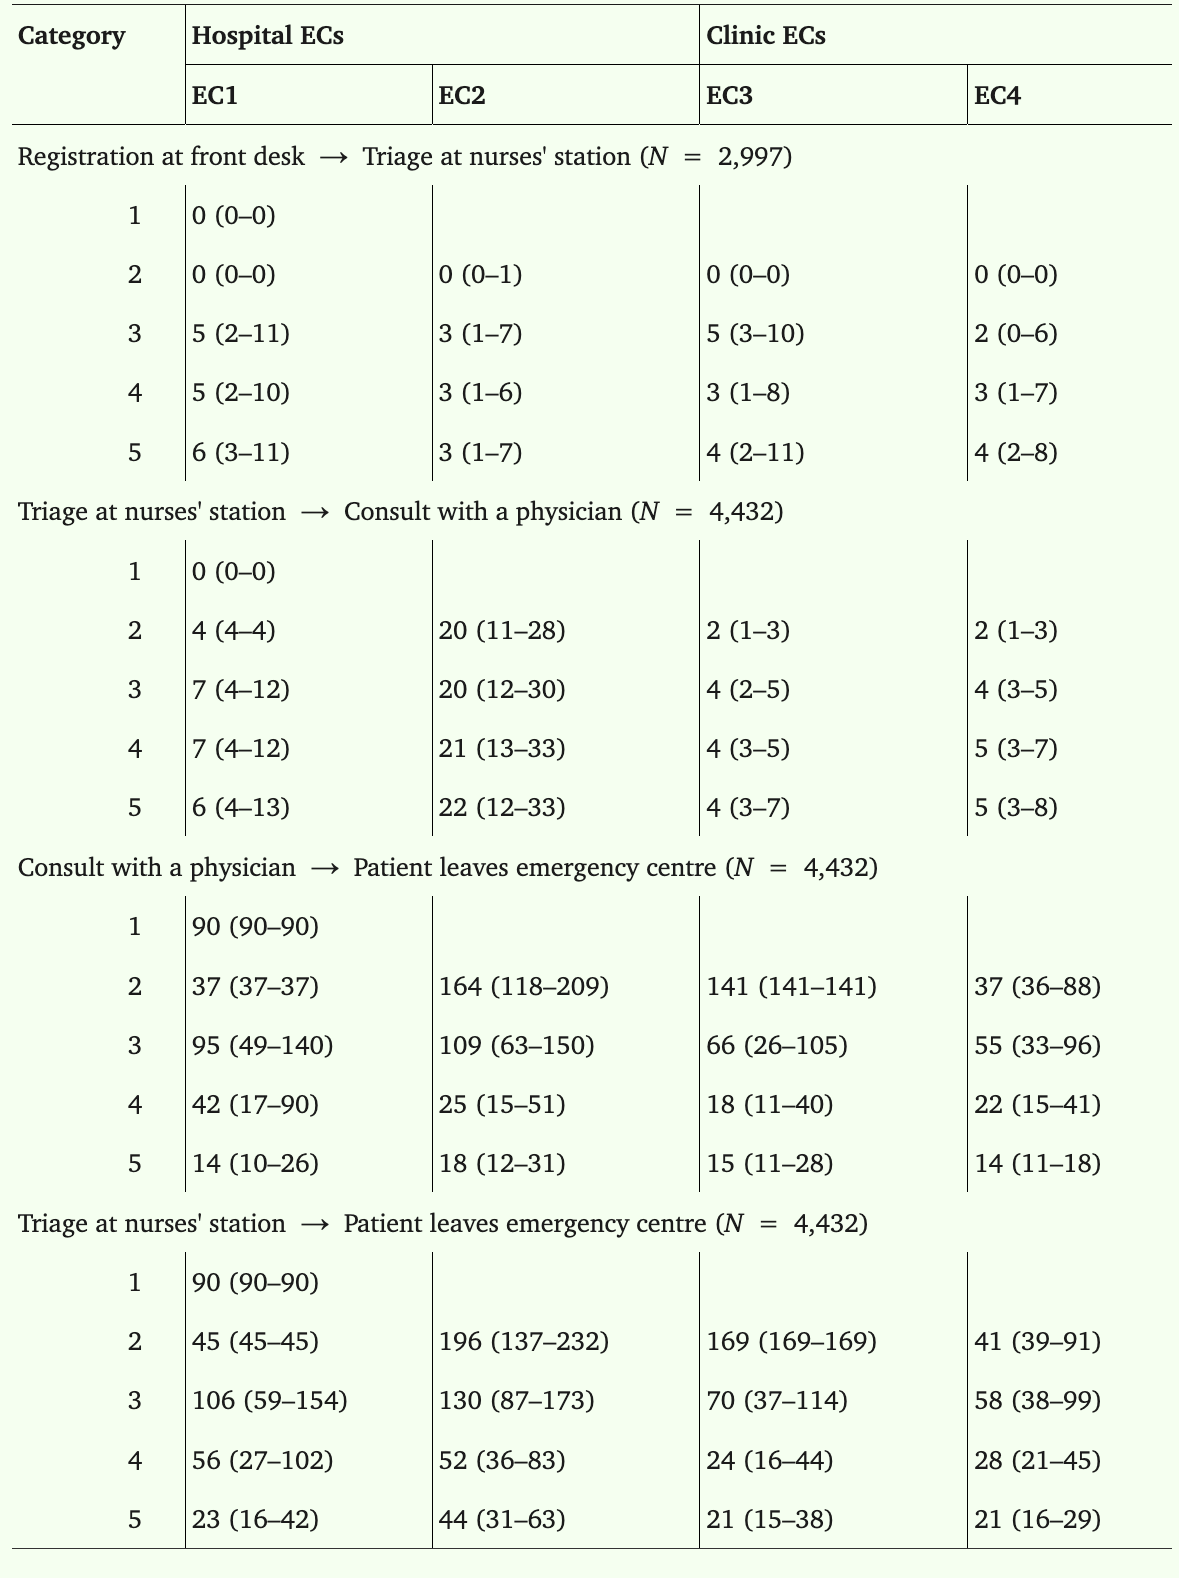

In [84]:
triage_probs = {
    1: 0.0002,
    2: 0.005,
    3: 0.249,
    4: 0.547,
    5: 0.199,
}
triage_probs = {k: v / sum(triage_probs.values()) for k, v in triage_probs.items()} # normalise to sum to 1

#  Assessment = triage at nurses station -> consult with physician using EC1 and EC2 as averages
# Discharge = triage -> leave department
timings_ec1 = {
    1: {
        "assessment": {"median": 0.0, "q1": 0.0, "q3": 0.0},
        "discharge": {"median": 90.0, "q1": 90.0, "q3": 90.0},
    },
    2: {
        "assessment": {"median": 0.0, "q1": 0.0, "q3": 0},
        "discharge": {"median": 45, "q1": 45, "q3": 45},
    },
    3: {
        "assessment": {"median": 5, "q1": 2, "q3": 11},
        "discharge": {"median": 106, "q1": 59, "q3": 154},
    },
    4: {
        "assessment": {"median": 5, "q1": 2, "q3": 11},
        "discharge": {"median": 56, "q1": 27, "q3": 102},
    },
    5: {
        "assessment": {"median": 6, "q1": 3, "q3": 11},
        "discharge": {"median": 23, "q1": 16, "q3": 42},
    },
}

timings_ec2 = {
    1: {
        "assessment": {"median": 0.0, "q1": 0.0, "q3": 0.0},
        "discharge": {"median": 90.0, "q1": 90.0, "q3": 90.0},
    },
    2: {
        "assessment": {"median": 0.0, "q1": 0.0, "q3": 1},
        "discharge": {"median": 196, "q1": 137, "q3": 232},
    },
    3: {
        "assessment": {"median": 3, "q1": 1, "q3": 7},
        "discharge": {"median": 130, "q1": 87, "q3": 173},
    },
    4: {
        "assessment": {"median": 3, "q1": 1, "q3": 6},
        "discharge": {"median": 52, "q1": 36, "q3": 83},
    },
    5: {
        "assessment": {"median": 3, "q1": 1, "q3": 7},
        "discharge": {"median": 44, "q1": 31, "q3": 63},
    },
}

timings = {}

for category in timings_ec1:
    timings[category] = {}
    for stage in timings_ec1[category]:
        timings[category][stage] = {}
        for stat in timings_ec1[category][stage]:
            timings[category][stage][stat] = round((timings_ec1[category][stage][stat] + timings_ec2[category][stage][stat]) / 2, 1)




In [85]:
def sample_minutes(median, q1, q3):
    '''
    Sample minutes from the distribution of timings for a given triage category and stage, using the median and intra-quartile range to estimate a normal distribution. 
    '''
    if q1 == q3 == median:
        return int(round(median))
    sd = max((q3 - q1) / 1.35, 1)
    x = np.random.normal(median, sd)
    return int(max(0, round(x)))

def make_timestamps(df):
    triage_time = df["arrival_time"] 
    
    assessment_delays = []
    treatment_delays = []
    discharge_delays = []
    
    for triage_id in df['triage_id']:
        stats = timings[triage_id]

        assessment_delay = sample_minutes(**stats["assessment"])
        discharge_delay = sample_minutes(**stats["discharge"])

        discharge_delay = max(discharge_delay, assessment_delay + 1)

        gap = discharge_delay - assessment_delay

        # earlier treatment for high risk patients
        if triage_id in [1, 2]:
            frac = np.random.uniform(0.05, 0.20)
        elif triage_id == 3:
            frac = np.random.uniform(0.10, 0.30)
        else:
            frac = np.random.uniform(0.20, 0.45)

        treatment_delay = assessment_delay + max(1, int(round(gap * frac)))
        treatment_delay = min(treatment_delay, discharge_delay - 1)

        assessment_delays.append(assessment_delay)
        discharge_delays.append(discharge_delay)
        treatment_delays.append(treatment_delay)

    df["first_assessment_time"] = triage_time + pd.to_timedelta(assessment_delays, unit="m")
    df["treatment_start_time"] = triage_time + pd.to_timedelta(treatment_delays, unit="m")
    df["discharge_time"] = triage_time + pd.to_timedelta(discharge_delays, unit="m")

    return df



In [86]:
n_visits = int(config["baseline"]["avg_ae_attendances"])


start = pd.Timestamp(config["start_date"])
end = start + pd.DateOffset(months=config["n_months"])
seconds_range = int((end - start).total_seconds())


visit_df = pd.DataFrame({
    "visit_id": range(1, n_visits + 1),
    "patient_id": np.random.randint(1, config["n_patients"] + 1, size=n_visits),
    "triage_id": np.random.choice(
        list(triage_probs.keys()),
        size=n_visits,
        p=list(triage_probs.values())
    ),
    "arrival_method_id": np.random.randint(1, 7, size=n_visits),
    "clinician_id": np.random.randint(1, config["n_clinicians"] + 1, size=n_visits),
    "department_id": 1,
    "outcome_id": np.random.choice([1, 2, 3, 4], size=n_visits, p=[0.70, 0.24, 0.03, 0.03]),
})


visit_df["arrival_time"] = start + pd.to_timedelta(
    np.random.randint(0, seconds_range, size=n_visits),
    unit="s"
)

visit_df = make_timestamps(visit_df)

visit_df.to_csv('../data/synthetic/_visits.csv', index=False)

